In [1]:
from functools import partial
import time

import matplotlib.pyplot as plt
import numpy as np
import numpy.typing as npt

from adaptive_swim.ansatz import BoundaryCompliantAnsatz
from swimpde.boundary import PeriodicStrict
from swimpde.domain import Domain
from swimpde.equation import Advection
from swimpde.solver import TimeDependentSolver

from utils import compute_metrics, plot_results

Parameters of the equation

In [2]:
def intial_condition(x: npt.ArrayLike) -> npt.ArrayLike:
    return np.sin(x) # u(x, 0) = sin(x)

def forcing(x: npt.ArrayLike, _: float) -> npt.ArrayLike:
    return np.zeros((x.shape[0], 1)) # No forcing term f(x, _) = 0 (time-independent)

def solution(x: npt.ArrayLike, t: float, beta: float) -> npt.ArrayLike:
    return np.sin(x - beta * t)

beta = 40
boundary_condition = PeriodicStrict()

x_span = 0, 2*np.pi
t_span = 0, 1

Create data for evaluation

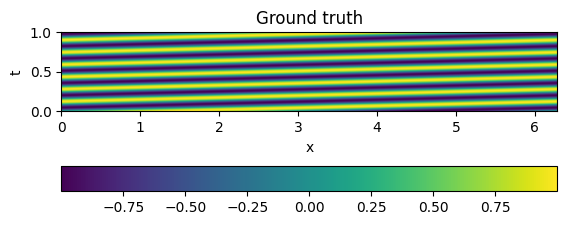

In [3]:
n_x_eval = 256
n_t_eval = 100


x_eval = np.linspace(*x_span, n_x_eval)[:, None]
t_eval = np.linspace(*t_span, n_t_eval)
u_exact = solution(x_eval, t_eval, beta)

# Visualize the solution.
fig, ax = plt.subplots(1)
im = ax.imshow(u_exact.T, extent=[*x_span, *t_span], origin="lower")
fig.colorbar(im, ax=ax, orientation="horizontal")
#ax.set_title(rf"Advection: $\beta$={beta}")
ax.set_title("Ground truth")
ax.set_xlabel("x")
ax.set_ylabel("t");

Create a domain

In [4]:
n_domain_points = 400 # collocation points in the spatial domain, N_c
x_space = np.linspace(*x_span, n_domain_points)[:, None]

x_interior = x_space[1:-1]
x_boundary = x_space[[0, -1]]
domain = Domain(interior_points=x_interior,
                boundary_points=x_boundary)

Solve the equation

In [5]:
# Parameters of the solver 
n_basis = 80 # number of outer basis functions, A\phi(x)
n_inner_basis = 800 # number of inner basis functions, random features, \phi = \sigma(Wx + b)
activation = "rational"
random_seed = 1
regularization_scale = 1e-11
rtol = 1e-10 # relative tolerance for ODE solver
atol = 1e-10

In [6]:
# A target for the basis functions.
# (target functions that already satisfy periodic BCs)
# Advection: sin(kx) for k even, cos(kx) for k odd
# Input: x (n_points, 1)
# Output: (n_points, n_basis)
def periodic_target_fn(x, n_basis):
    # We need to create one extra function if n_basis is odd.
    n_pairs = (n_basis + 1) // 2
    scales = np.arange(1, n_pairs + 1)
    sin_transforms = np.sin(x * scales)
    cos_transforms = np.cos(x * scales)
    transforms = np.column_stack([sin_transforms, cos_transforms])
    # Cut this extra function out if n_basis is odd.
    return transforms[:, :n_basis]


# Define the ansatz A\phi(x).
ansatz = BoundaryCompliantAnsatz(
    n_basis=n_basis,
    n_inner_basis=n_inner_basis,
    activation=activation,
    random_seed=random_seed,
    target_fn=partial(periodic_target_fn, n_basis=n_basis),
    boundary_condition=boundary_condition,
    regularization_scale=regularization_scale,
    initial_condition=intial_condition,
    k=10,
    s=0.5,
)

# Define the equation.
equation = Advection(u0=intial_condition, beta=beta)

# Define the solver.
solver = TimeDependentSolver(
    domain=domain,
    ansatz=ansatz,
    forcing=forcing,
    equation=equation,
    regularization_scale=regularization_scale,
    rtol=rtol,
    atol=atol,
)

# Fit the solver.
start_fit = time.time()
solver.fit(t_span=t_span)
end_fit = time.time()
training_time = end_fit - start_fit

print(f"Training time: {training_time:.4f}s")


Training time: 1.5336s


Evaluate the solver

Relative error: 1.307E-07
398 2 256


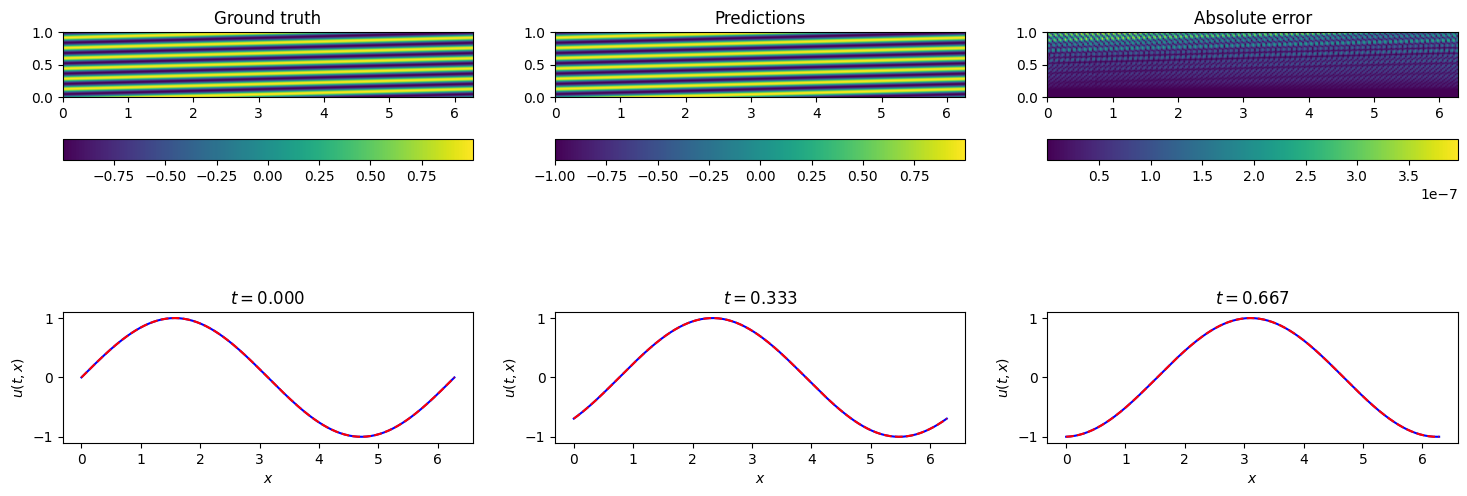

In [7]:
u_pred = solver.evaluate(x_eval, t_eval)
abs_error, rel_l2_error = compute_metrics(u_pred, u_exact)

print(fr"Relative error: {rel_l2_error:.3E}")
fig = plot_results(x_eval, t_eval, u_exact, u_pred, abs_error)
print(len(x_interior), len(x_boundary), len(x_eval))